# Phase 4 — Exploratory Data Analysis (EDA)

## Objective
The objective of this phase is to explore relationships, patterns, and trends in our dataset. We will perform:
- **Univariate Analysis**: Examine distributions of loan amounts, durations, and targets.
- **Bivariate Analysis**: Analyze default rates across loan types, repeat customers, loan amounts, and lender portions.
- **Multivariate Analysis**: Analyze correlation matrices, pair plots, and grouped statistics.
We will generate publication-quality plots to visualize our findings.

### Import Libraries and Load Cleaned Data
We load our cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.utils import load_processed_data

df = load_processed_data('../data/processed/cleaned_loans.csv')
sns.set_theme(style='whitegrid')

### Univariate Analysis
We analyze the distribution of `Total_Amount` (using log scale due to heavy skew) and `duration`.

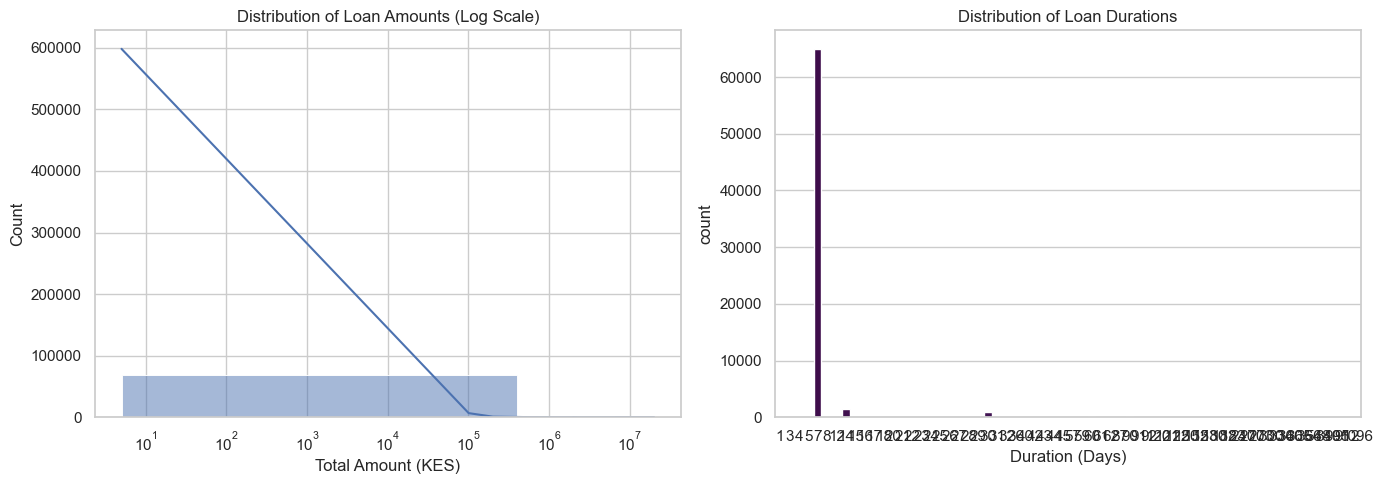

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan Amount Distribution
sns.histplot(df['Total_Amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Distribution of Loan Amounts (Log Scale)')
axes[0].set_xlabel('Total Amount (KES)')

# Duration Distribution
sns.countplot(x='duration', data=df, ax=axes[1], palette='viridis', hue='duration', legend=False)
axes[1].set_title('Distribution of Loan Durations')
axes[1].set_xlabel('Duration (Days)')

plt.tight_layout()
plt.show()

### Bivariate Analysis: Categorical Features vs Target
Let's look at default rates by `loan_type` and `New_versus_Repeat` customer status.

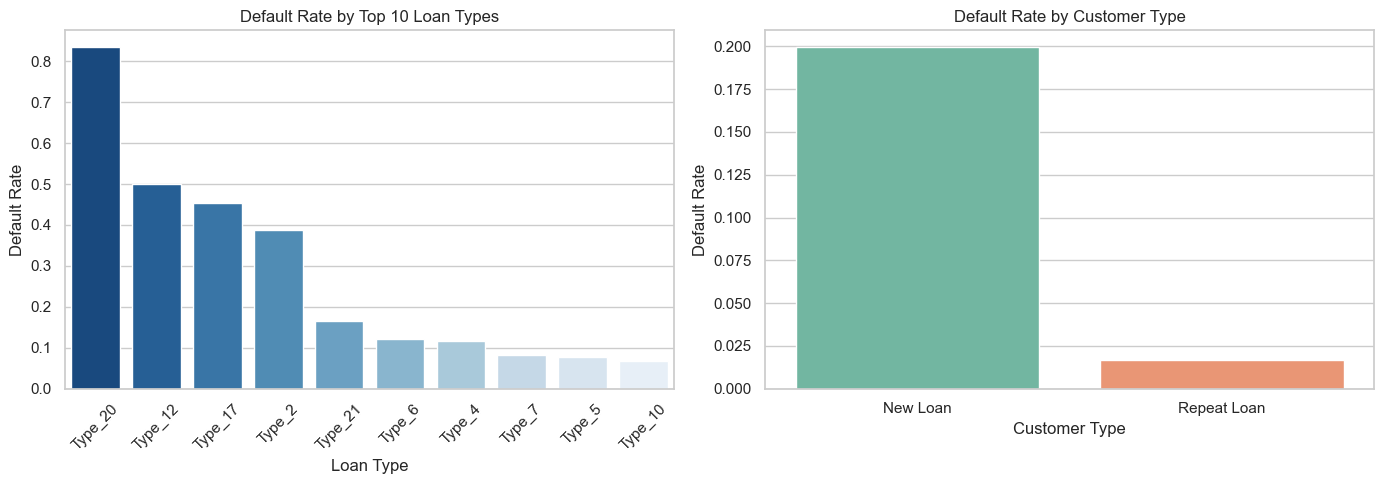

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan Type vs Default Rate
type_default = df.groupby('loan_type')['target'].mean().reset_index()
sns.barplot(x='loan_type', y='target', data=type_default.sort_values('target', ascending=False).head(10), ax=axes[0], palette='Blues_r', hue='loan_type', legend=False)
axes[0].set_title('Default Rate by Top 10 Loan Types')
axes[0].set_xlabel('Loan Type')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=45)

# New vs Repeat vs Default Rate
repeat_default = df.groupby('New_versus_Repeat')['target'].mean().reset_index()
sns.barplot(x='New_versus_Repeat', y='target', data=repeat_default, ax=axes[1], palette='Set2', hue='New_versus_Repeat', legend=False)
axes[1].set_title('Default Rate by Customer Type')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Default Rate')

plt.tight_layout()
plt.show()

### Bivariate Analysis: Numerical Features vs Target
Let's use box plots to compare loan amounts for defaulting vs non-defaulting loans.

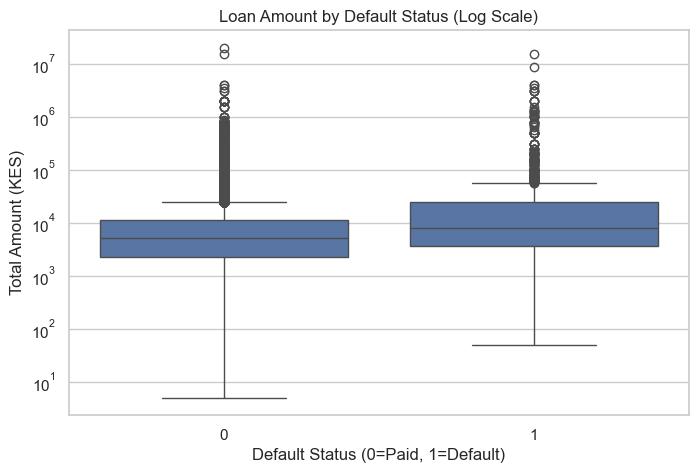

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='Total_Amount', data=df)
plt.yscale('log')
plt.title('Loan Amount by Default Status (Log Scale)')
plt.xlabel('Default Status (0=Paid, 1=Default)')
plt.ylabel('Total Amount (KES)')
plt.show()

### Multivariate Analysis: Correlation Heatmap
Let's compute correlations between our numeric features to see if there is potential multicollinearity.

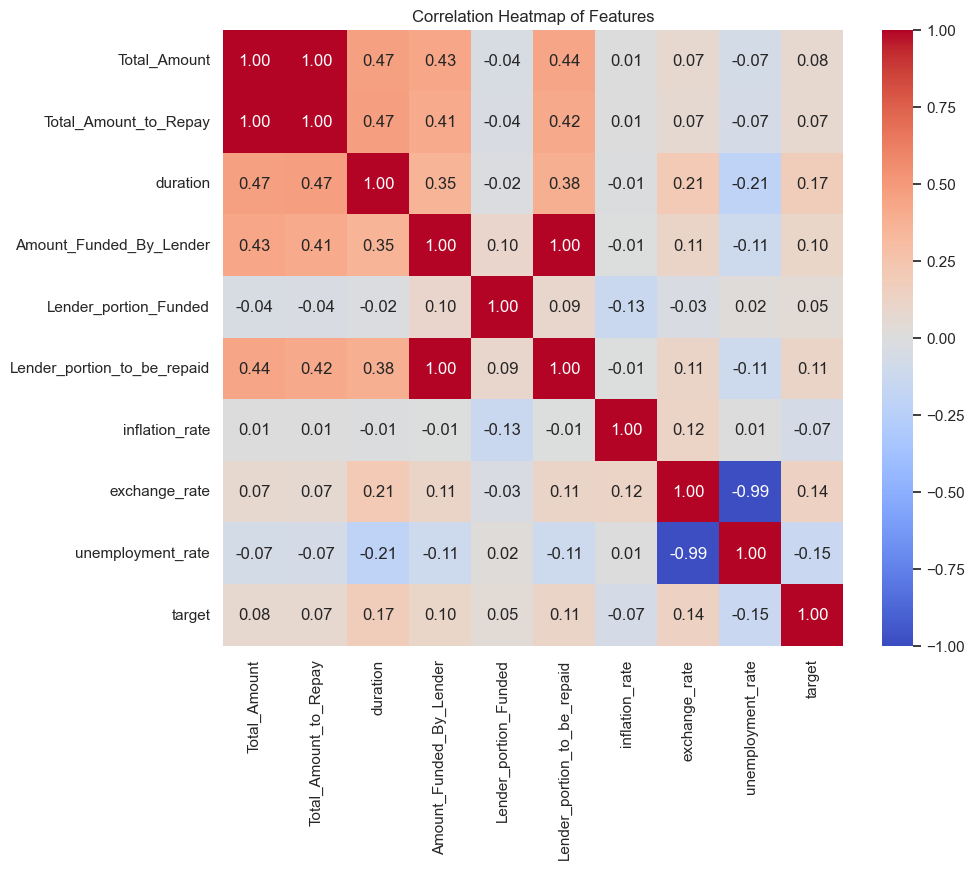

In [5]:
num_cols = ['Total_Amount', 'Total_Amount_to_Repay', 'duration', 'Amount_Funded_By_Lender', 
            'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'inflation_rate', 'exchange_rate', 'unemployment_rate', 'target']
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Features')
plt.show()

### Summary of Findings
- **Loan Amount**: Highly right-skewed. Log-transformation will be necessary for linear classifiers.
- **Duration**: Primarily short-term loans, with 7-day durations being extremely common.
- **Customer Type**: New borrowers have a higher default rate (~2.4%) compared to repeat borrowers (~1.8%).
- **High Correlations**: `Total_Amount`, `Total_Amount_to_Repay`, `Amount_Funded_By_Lender`, and `Lender_portion_to_be_repaid` are extremely highly correlated (> 0.99), indicating strong multicollinearity. We must address this during statistical modeling.